En este cuaderno probaremos diversas normalizaciones junto al modelo basado en Redes neuronales Densas.
Primero cargamos los datos que usaremos.

In [1]:
import os

os.environ["NUMEXPR_MAX_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

import numpy as np
from pathlib import Path

processed_path = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/splits/processed_data.npz")

data = np.load(processed_path)

print(data.files)

['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'gaia_wavelength', 'sdss_wavelength']


In [2]:
# Datos de entrada Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos objetivo SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

Probamos ahora una normalización basada en la media aritmética de todos los espectros observados en el conjunto de entrenamiento. 

In [3]:
# Normalizamos los datos
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_norm_global = (X_train - X_mean) / X_std
X_val_norm_global = (X_val - X_mean) / X_std
X_test_norm_global = (X_test - X_mean) / X_std

y_train_norm_global = (y_train - y_mean) / y_std
y_val_norm_global = (y_val - y_mean) / y_std
y_test_norm_global = (y_test - y_mean) / y_std

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt

n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

# Definimos el modelo a usar
model = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta = 1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

Entrenamos el modelo

In [6]:
history_norm_global = model.fit(
    X_train_norm_global,
    y_train_norm_global,
    validation_data=(X_val_norm_global, y_val_norm_global),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - loss: 0.0643 - mae: 0.2071 - mse: 0.1573 - val_loss: 0.0125 - val_mae: 0.0885 - val_mse: 0.0276 - learning_rate: 1.0000e-04
Epoch 2/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - loss: 0.0122 - mae: 0.0895 - mse: 0.0257 - val_loss: 0.0115 - val_mae: 0.0864 - val_mse: 0.0255 - learning_rate: 1.0000e-04
Epoch 3/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - loss: 0.0114 - mae: 0.0861 - mse: 0.0243 - val_loss: 0.0159 - val_mae: 0.1068 - val_mse: 0.0347 - learning_rate: 1.0000e-04
Epoch 4/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0111 - mae: 0.0853 - mse: 0.0240
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
489/489 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - loss: 0.0111 - mae: 0.0853 - mse: 0.0240 - val_loss: 0.0120 - val_mae: 0.0914 - val_mse: 0.0265 - learning_rate: 1.0000e-04
Epoch 5/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - loss: 0.0100 - mae: 0.0804 - mse: 0.0217 - val_loss: 0.0102 - v

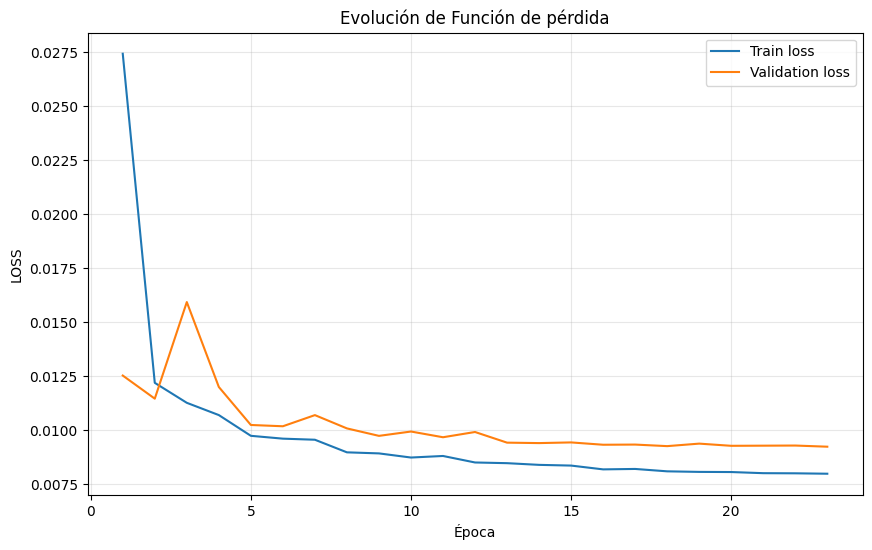

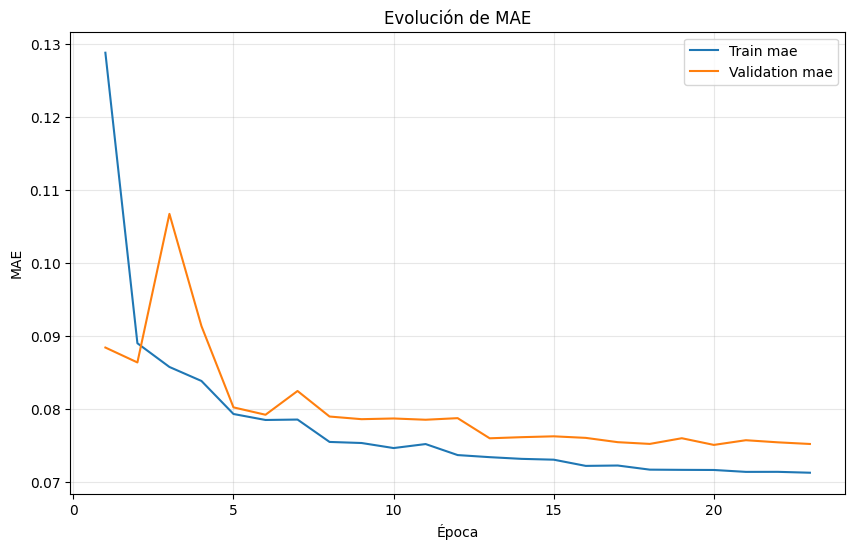

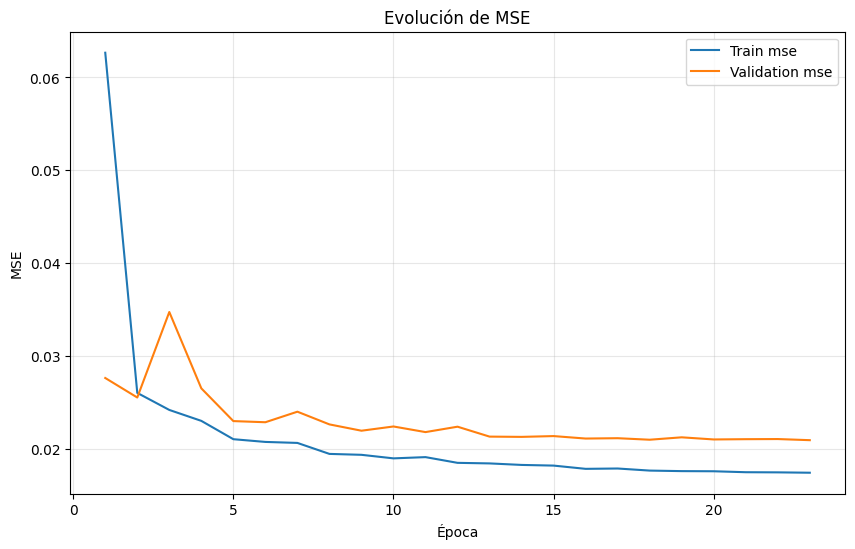

In [7]:
model_data_norm_global = history_norm_global.history
epochs = range(1, len(model_data_norm_global["loss"]) + 1)

metrics = [
    ("loss", "Función de pérdida"),
    ("mae", "MAE"),
    ("mse", "MSE")
]

for metric, title in metrics:
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, model_data_norm_global[metric], label=f"Train {metric}")
    plt.plot(epochs, model_data_norm_global[f"val_{metric}"], label=f"Validation {metric}")

    plt.xlabel("Época")
    plt.ylabel(metric.upper())
    plt.title(f"Evolución de {title}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [8]:
# Predecimos y sobre el conjunto de test
y_pred_norm_global = model.predict(X_test_norm_global)
y_pred_global = y_pred_norm_global * y_std + y_mean

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Graficamos un par de ejemplos

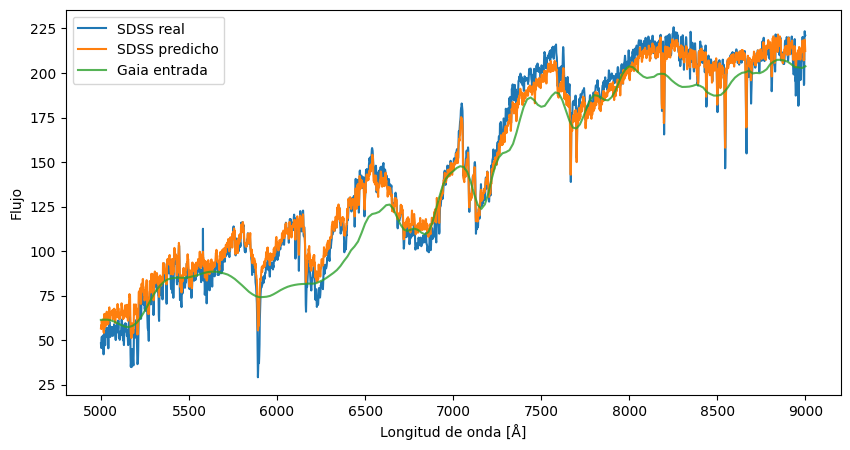

In [9]:
i = 123

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_global[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

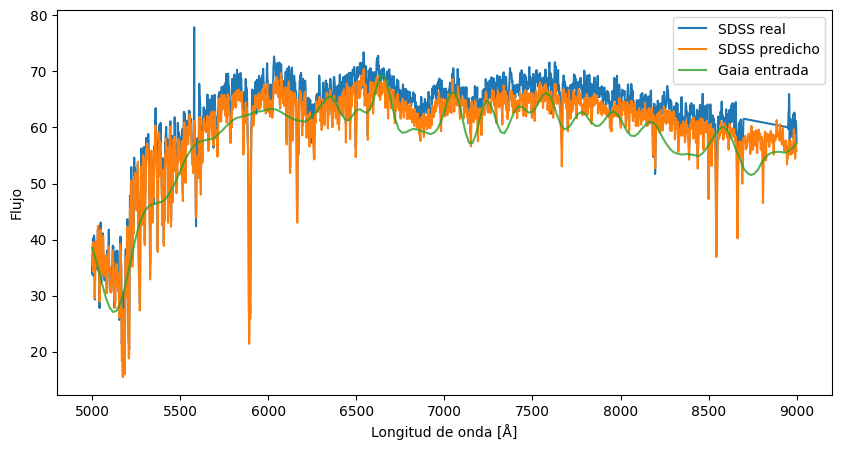

In [10]:
i = 191

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_global[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

In [11]:
test_loss, test_mae, test_mse = model.evaluate(
    X_test_norm_global,
    y_test_norm_global,
    verbose=1
)

306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0087 - mae: 0.0735 - mse: 0.0183


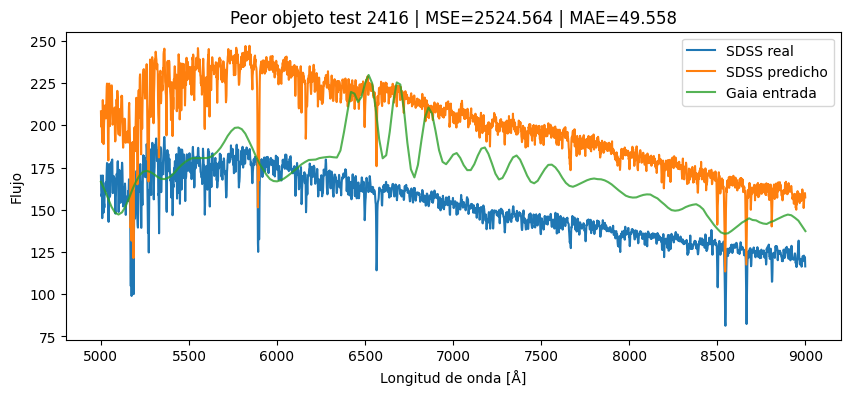

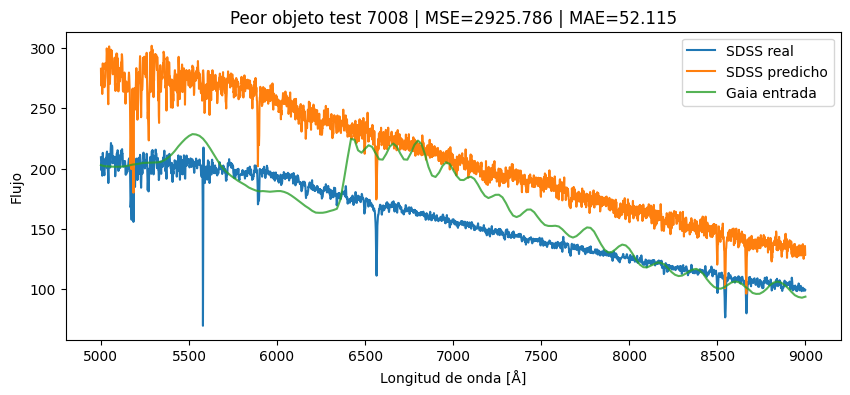

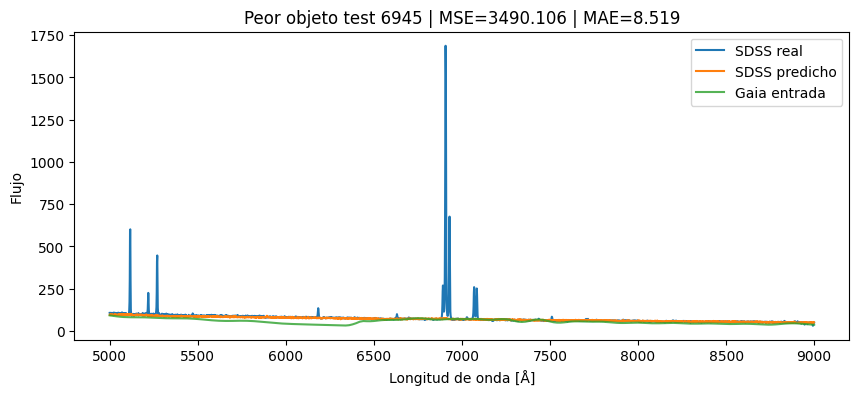

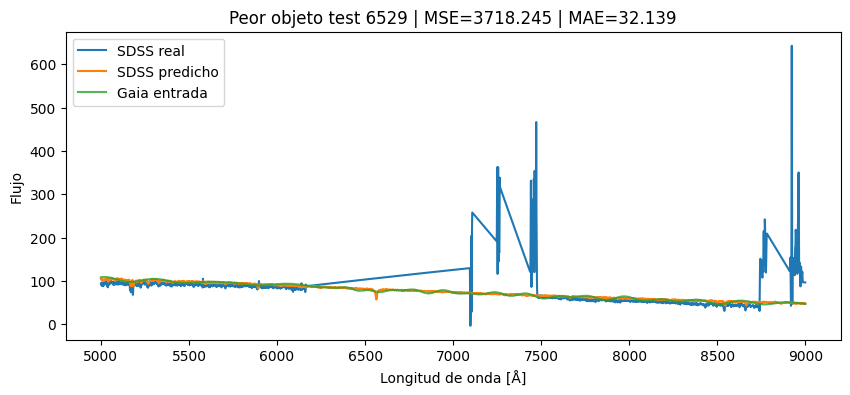

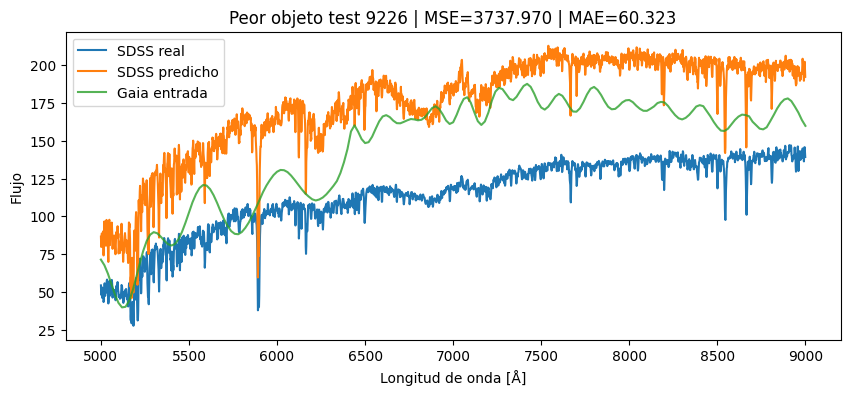

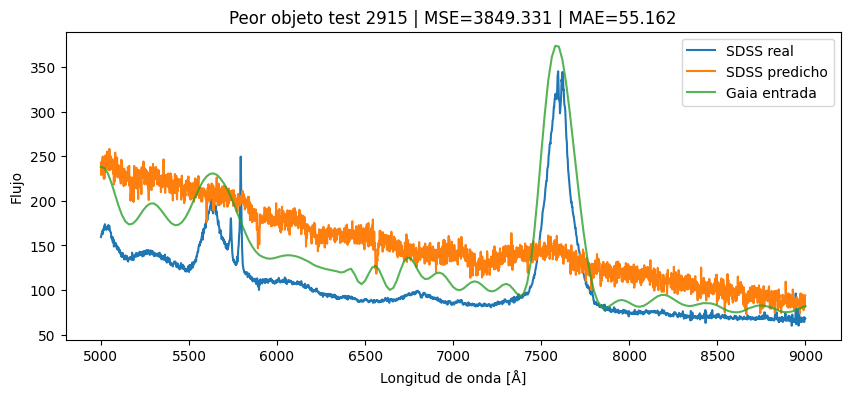

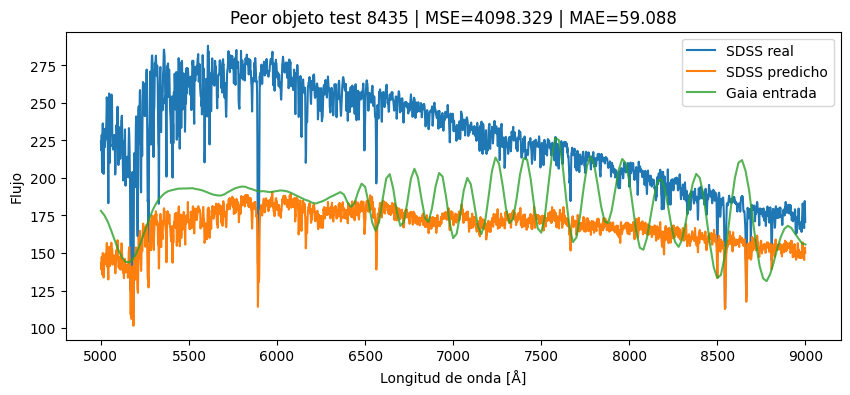

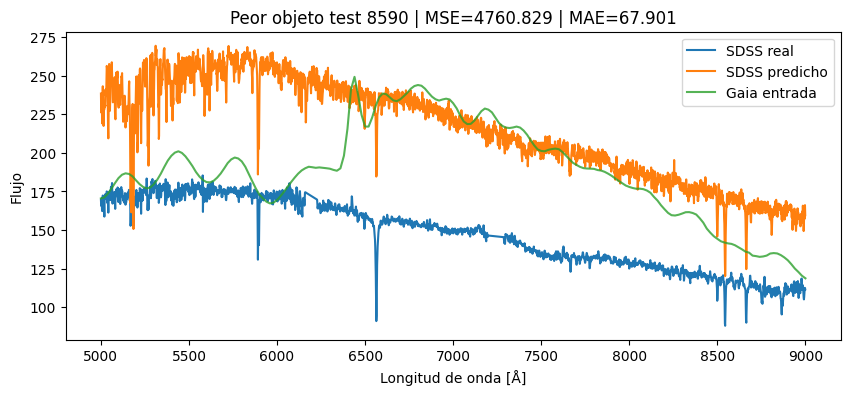

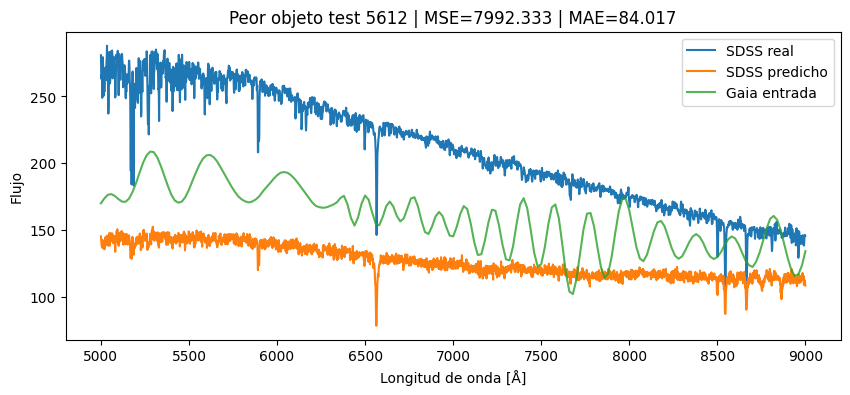

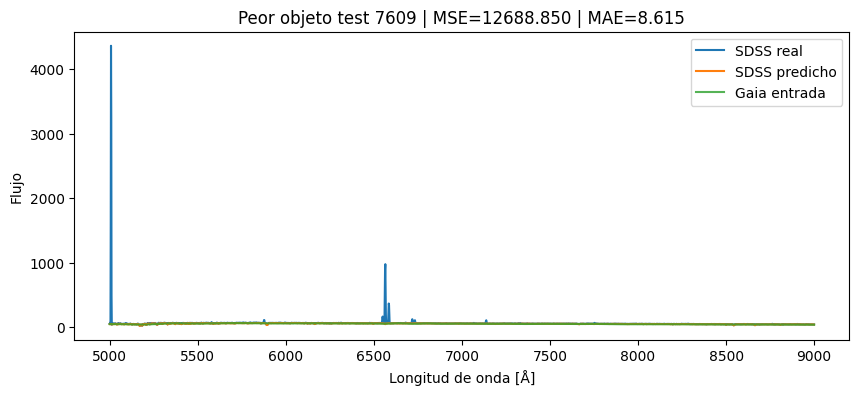

In [13]:
mae = np.mean(np.abs(y_test - y_pred_global))
mse = np.mean((y_test - y_pred_global) ** 2)
rmse = np.sqrt(mse)

mae_per_object = np.mean(np.abs(y_test - y_pred_global), axis=1)
mse_per_object = np.mean((y_test - y_pred_global) ** 2, axis=1)
rmse_per_object = np.sqrt(mse_per_object)

worst_idx = np.argsort(mse_per_object)[-10:]

for i in worst_idx:

    plt.figure(figsize=(10, 4))
    plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength, y_pred_global[i], label="SDSS predicho")
    plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Peor objeto test {i} | MSE={mse_per_object[i]:.3f} | MAE={mae_per_object[i]:.3f}")
    plt.legend()
    plt.show()

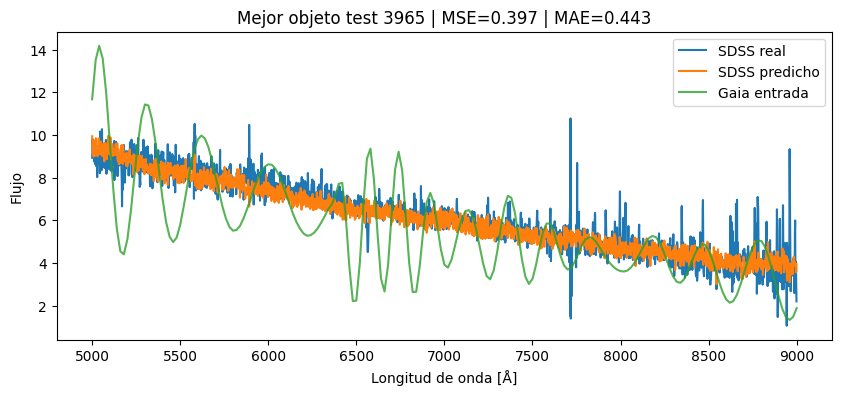

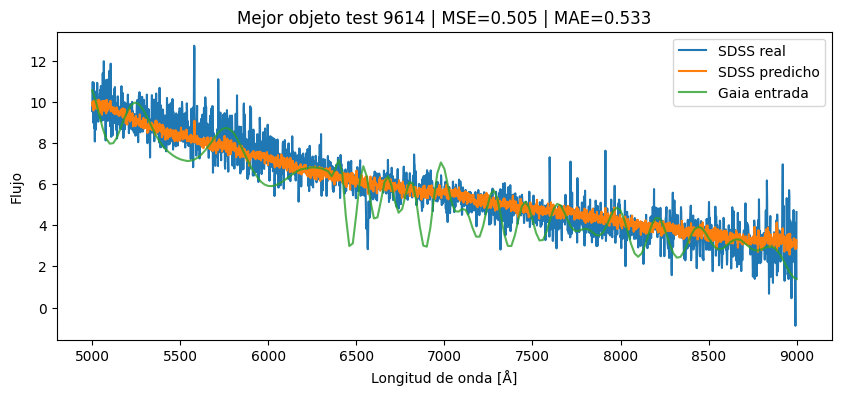

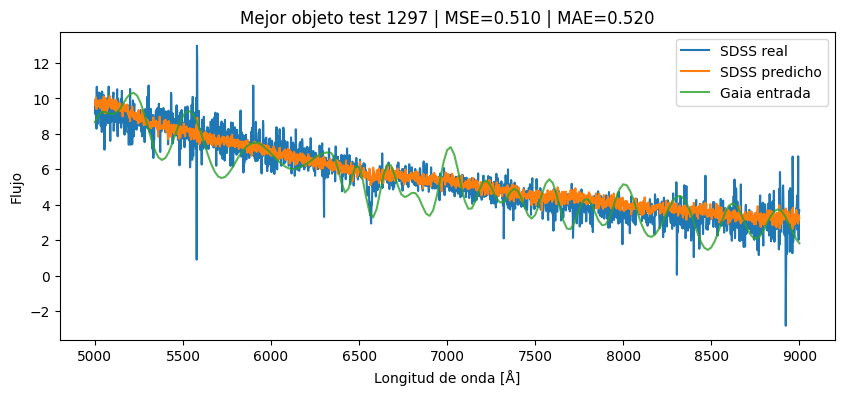

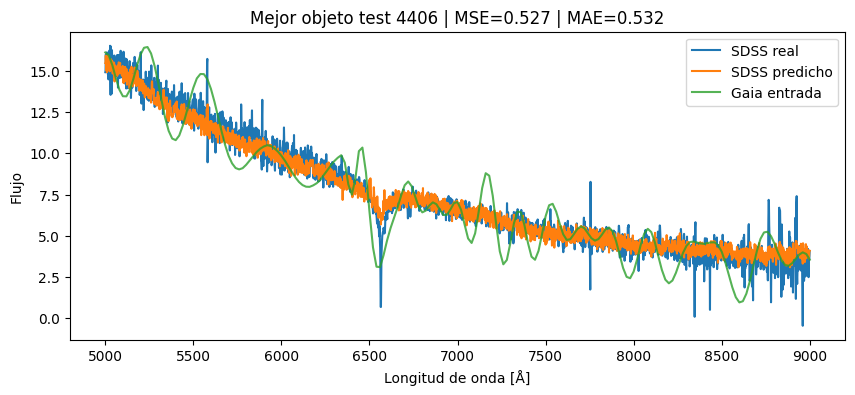

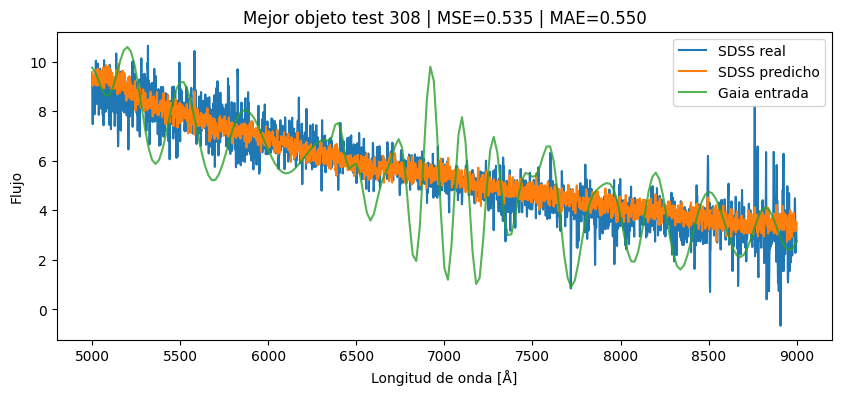

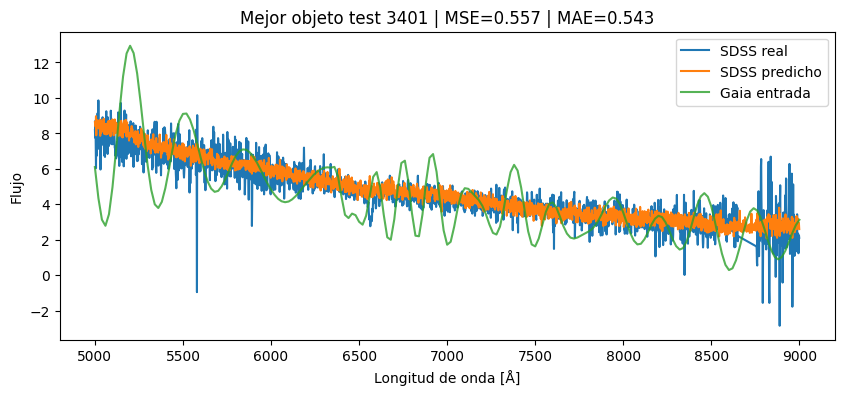

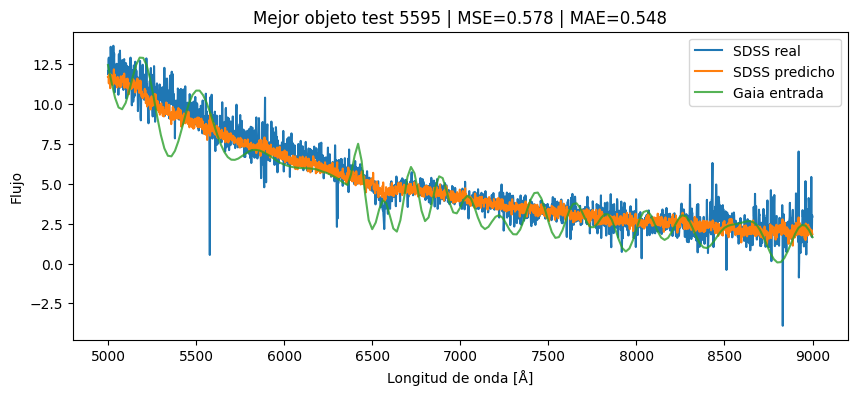

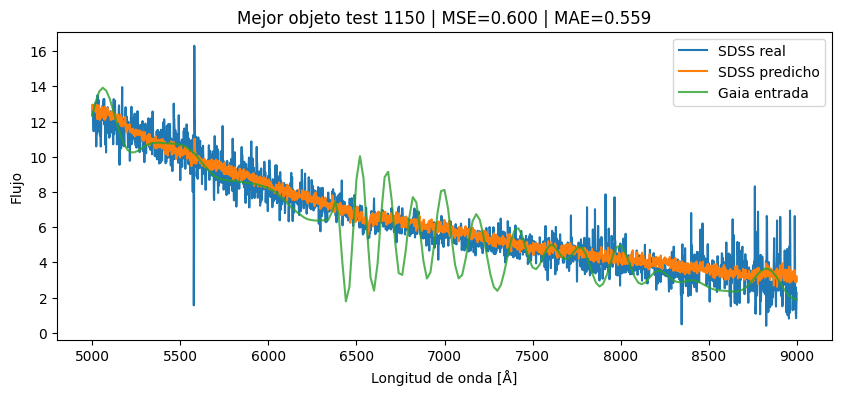

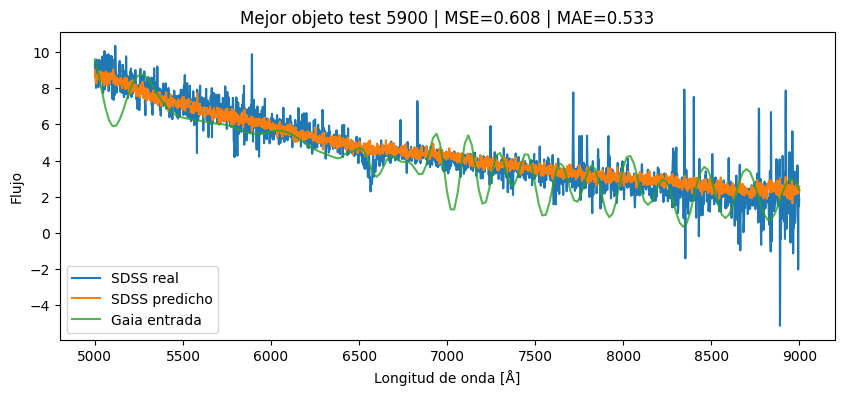

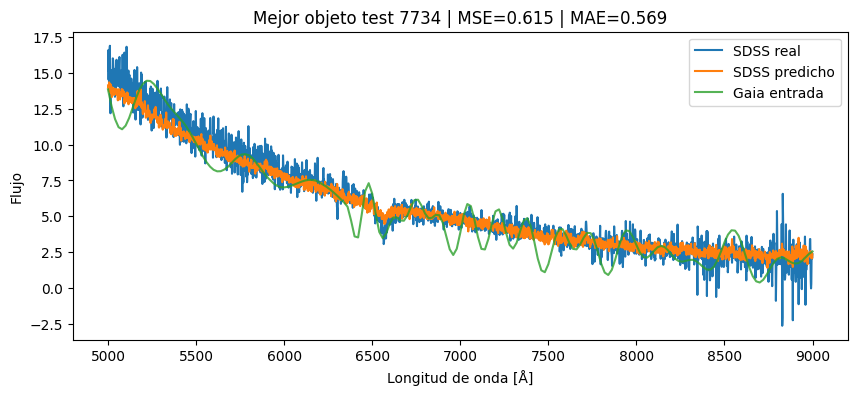

In [14]:
best_idx = np.argsort(mse_per_object)[:10]

for i in best_idx:
    plt.figure(figsize=(10, 4))
    plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength, y_pred_global[i], label="SDSS predicho")
    plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Mejor objeto test {i} | MSE={mse_per_object[i]:.3f} | MAE={mae_per_object[i]:.3f}")
    plt.legend()
    plt.show()

Añadimos código para comprobar los valores sacados con iSpec del espectro real y predicho. 

In [15]:
import sys
from pathlib import Path

ISPEC_FUNCTIONS_DIR = Path(
    "/Users/carlasequero/Desktop/trabajo-fin-master/solution/models"
)

if str(ISPEC_FUNCTIONS_DIR) not in sys.path:
    sys.path.insert(0, str(ISPEC_FUNCTIONS_DIR))

In [16]:
# Importamos Funciones iSpec
from iSpec_functions import (
    load_ispec_resources,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)

In [17]:
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2

In [18]:
# Cargamos Resources
resources = load_ispec_resources()


Recursos de iSpec cargados correctamente.


In [19]:
from astropy.table import Table
# Cargamos la tabla de Gaia guardada en local
gaia_data_table = Table.read(
    "/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/"
    "gaia_data.ecsv",
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()

In [20]:
# Analizamos y devolvemos DF con valores ajustados a los espectros
results_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_global,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=25
    )

Espectros analizados:   0%|          | 0/25 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE


[2026-08-15 16:44:54,137] [WARNING] [atmospheres:_interpolate:114]: Target point '4557.640079045548 5.5 -0.4621298868728796' is out of bound, using the closest
[2026-08-15 16:46:14,922] [WARNING] [atmospheres:_interpolate:114]: Target point '4642.379659757796 5.5 -0.6895095800716907' is out of bound, using the closest


Only LTE


[2026-08-15 16:46:44,183] [WARNING] [atmospheres:_interpolate:114]: Target point '4533.434076024611 5.5 -0.43870382171517436' is out of bound, using the closest
[2026-08-15 16:47:59,061] [WARNING] [atmospheres:_interpolate:114]: Target point '4559.591592807346 5.4378886856428785 -0.6904098088735547' is out of bound, using the closest


...

Only LTE


[2026-08-15 17:35:59,226] [WARNING] [atmospheres:_interpolate:114]: Target point '5759.473130074174 5.5 -0.6587363832656777' is out of bound, using the closest
[2026-08-15 17:36:42,048] [WARNING] [atmospheres:_interpolate:114]: Target point '5134.870625276517 5.403312386819402 -1.5722641900266279' is out of bound, using the closest


Only LTE


[2026-08-15 17:37:53,710] [WARNING] [atmospheres:_interpolate:114]: Target point '5838.751064266897 5.5 -0.6482827290133506' is out of bound, using the closest


Only LTE
Only LTE
Only LTE
Only LTE
Only LTE


In [21]:
display(results_df)


,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh
0,5565,3671235824399765248,5963.205566,4.6555,-3.9715,5963.205566,4.655500,-3.971500,6118.843888,4.738653,-3.353029,155.638321,0.083153,0.618470
1,704,3704203340528495232,6325.838867,4.5677,-3.4026,6325.838867,4.567700,-3.402600,6325.838867,4.567700,-3.402600,0.000000,0.000000,0.000000
2,854,6897655664207892480,4370.357910,4.5324,0.0080,4655.804744,5.396502,-0.850963,4733.407458,5.339884,-0.861118,77.602713,-0.056617,-0.010155
3,4907,2537910232635089152,3500.701904,4.8270,-0.1623,2670.249129,2.506321,-4.092748,3459.938211,4.442980,-0.848032,789.689082,1.936659,3.244716
4,6399,2542848242435403520,4895.759277,4.1958,-0.5936,5071.433399,5.006137,-0.929676,4948.421801,5.035378,-1.175768,-123.011598,0.029241,-0.246092
5,565,812942132658055680,6623.798828,4.5930,-3.3315,6656.449025,4.580418,-3.355173,6623.798828,4.593000,-3.331500,-32.650197,0.012582,0.023673
6,1976,1539343770972883328,5787.617188,4.6700,-1.0899,5863.860173,4.747396,-1.066439,5856.699060,4.704463,-1.045416,-7.161113,-0.042933,0.021023
7,2108,3712143326310039680,6364.312012,4.4456,-4.0892,6365.278049,4.447181,-3.115839,6365.552953,4.447258,-3.604035,0.274903,0.000077,-0.488196
8,9612,5175449442950166016,6152.113770,4.5024,-0.8777,6168.809610,4.517876,-0.857787,6213.603082,4.544050,-0.854730,44.793472,0.026174,0.003057
9,8177,1331882861867151360,6623.420898,4.5788,-3.4914,6638.606950,4.593235,-3.496615,6648.892834,4.604370,-3.506297,10.285883,0.011135,-0.009683


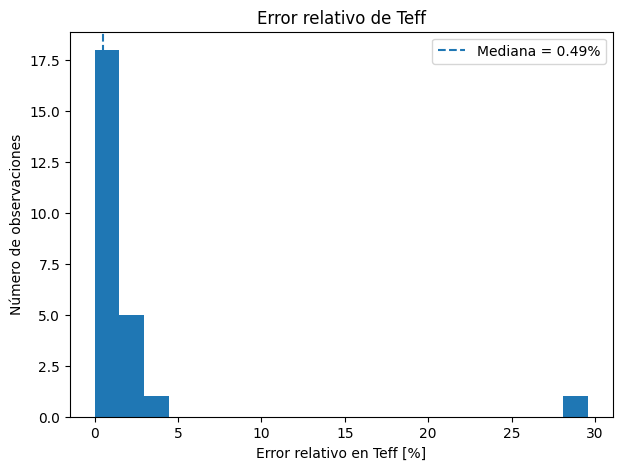

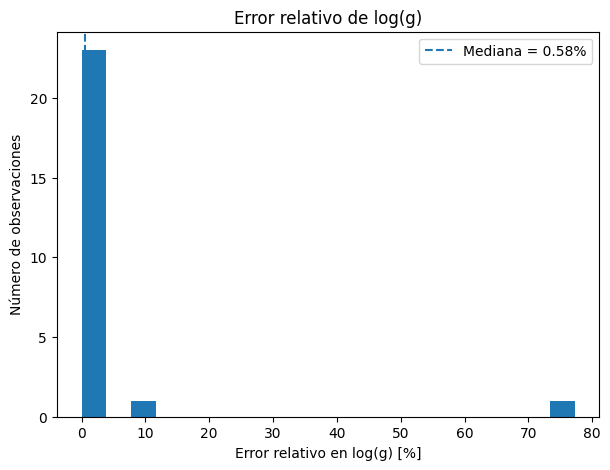

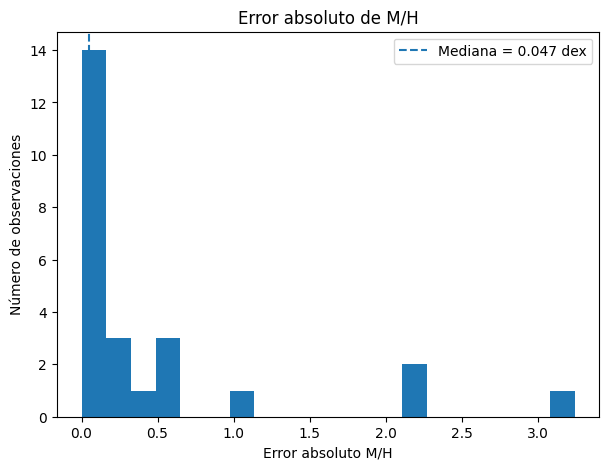

In [22]:
error_df = analyze_ispec_errors(results_df)

In [23]:
display(error_df)

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,5565,3671235824399765248,5963.205566,4.6555,-3.9715,5963.205566,4.655500,-3.971500,6118.843888,4.738653,-3.353029,155.638321,0.083153,0.618470,155.638321,0.083153,0.618470,2.609977,1.786134
1,704,3704203340528495232,6325.838867,4.5677,-3.4026,6325.838867,4.567700,-3.402600,6325.838867,4.567700,-3.402600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,854,6897655664207892480,4370.357910,4.5324,0.0080,4655.804744,5.396502,-0.850963,4733.407458,5.339884,-0.861118,77.602713,-0.056617,-0.010155,77.602713,0.056617,0.010155,1.666795,1.049148
3,4907,2537910232635089152,3500.701904,4.8270,-0.1623,2670.249129,2.506321,-4.092748,3459.938211,4.442980,-0.848032,789.689082,1.936659,3.244716,789.689082,1.936659,3.244716,29.573611,77.270967
4,6399,2542848242435403520,4895.759277,4.1958,-0.5936,5071.433399,5.006137,-0.929676,4948.421801,5.035378,-1.175768,-123.011598,0.029241,-0.246092,123.011598,0.029241,0.246092,2.425578,0.584106
5,565,812942132658055680,6623.798828,4.5930,-3.3315,6656.449025,4.580418,-3.355173,6623.798828,4.593000,-3.331500,-32.650197,0.012582,0.023673,32.650197,0.012582,0.023673,0.490505,0.274700
6,1976,1539343770972883328,5787.617188,4.6700,-1.0899,5863.860173,4.747396,-1.066439,5856.699060,4.704463,-1.045416,-7.161113,-0.042933,0.021023,7.161113,0.042933,0.021023,0.122123,0.904347
7,2108,3712143326310039680,6364.312012,4.4456,-4.0892,6365.278049,4.447181,-3.115839,6365.552953,4.447258,-3.604035,0.274903,0.000077,-0.488196,0.274903,0.000077,0.488196,0.004319,0.001730
8,9612,5175449442950166016,6152.113770,4.5024,-0.8777,6168.809610,4.517876,-0.857787,6213.603082,4.544050,-0.854730,44.793472,0.026174,0.003057,44.793472,0.026174,0.003057,0.726128,0.579345
9,8177,1331882861867151360,6623.420898,4.5788,-3.4914,6638.606950,4.593235,-3.496615,6648.892834,4.604370,-3.506297,10.285883,0.011135,-0.009683,10.285883,0.011135,0.009683,0.154940,0.242425


Intentamos el mismo modelo pero con normalización espectro a espectro con la mediana.

In [24]:
X_scale_train = np.nanmedian(np.abs(X_train), axis=1, keepdims=True)
X_scale_val = np.nanmedian(np.abs(X_val), axis=1, keepdims=True)
X_scale_test = np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

y_scale_train = np.nanmedian(np.abs(y_train), axis=1, keepdims=True)
y_scale_val = np.nanmedian(np.abs(y_val), axis=1, keepdims=True)
y_scale_test = np.nanmedian(np.abs(y_test), axis=1, keepdims=True)

X_train_norm_median_spec = X_train / X_scale_train
X_val_norm_median_spec = X_val / X_scale_val
X_test_norm_median_spec = X_test / X_scale_test

y_train_norm_median_spec = y_train / y_scale_train
y_val_norm_median_spec = y_val / y_scale_val
y_test_norm_median_spec = y_test / y_scale_test

In [25]:
n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

model_median_spec = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),#, activation="elu"),#relu
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_median_spec.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_median_spec.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Entrenamos el modelo
history = model_median_spec.fit(
    X_train_norm_median_spec,
    y_train_norm_median_spec,
    validation_data=(X_val_norm_median_spec, y_val_norm_median_spec),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - loss: 0.0689 - mae: 0.2043 - mse: 0.1572 - val_loss: 0.0066 - val_mae: 0.0612 - val_mse: 0.0190 - learning_rate: 1.0000e-04
Epoch 2/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 0.0063 - mae: 0.0608 - mse: 0.0161 - val_loss: 0.0063 - val_mae: 0.0597 - val_mse: 0.0183 - learning_rate: 1.0000e-04
Epoch 3/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.0058 - mae: 0.0580 - mse: 0.0149 - val_loss: 0.0060 - val_mae: 0.0584 - val_mse: 0.0178 - learning_rate: 1.0000e-04
Epoch 4/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 0.0061 - mae: 0.0590 - mse: 0.0159 - val_loss: 0.0057 - val_mae: 0.0548 - val_mse: 0.0169 - learning_rate: 1.0000e-04
Epoch 5/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.0054 - mae: 0.0558 - mse: 0.0135 - val_loss: 0.0058 - val_mae: 0.0566 - val_mse: 0.0170 - learning_rate: 1.0000e-04
Epoch 6/50
487/489 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0054 - mae: 0.0565 - mse: 0.0138
Epoc

In [27]:
y_pred_norm_median_spec = model_median_spec.predict(X_test_norm_median_spec)
y_pred_median_spec = y_pred_norm_median_spec* y_scale_test

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [28]:
test_loss_median_spec, test_mae_median_spec, test_mse_median_spec = model_median_spec.evaluate(
    X_test_norm_median_spec,
    y_test_norm_median_spec,
    verbose=1
)

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0045 - mae: 0.0488 - mse: 0.0126


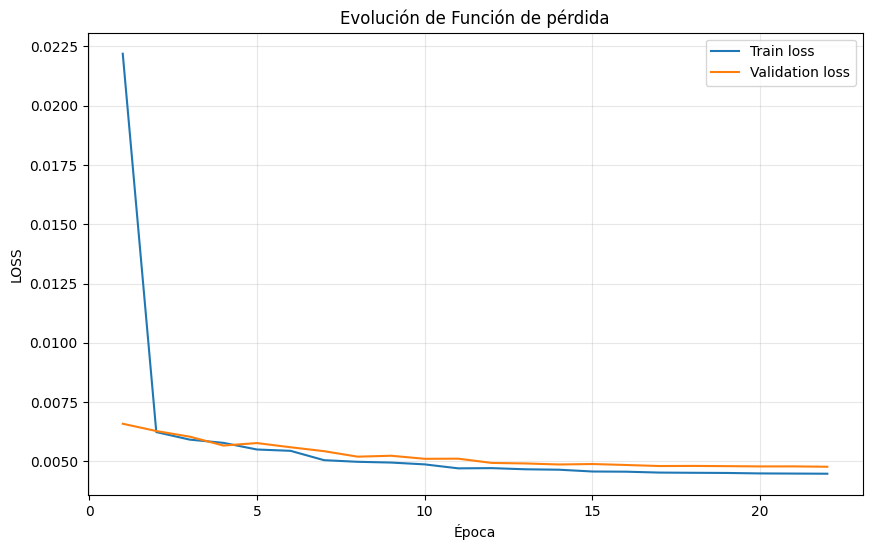

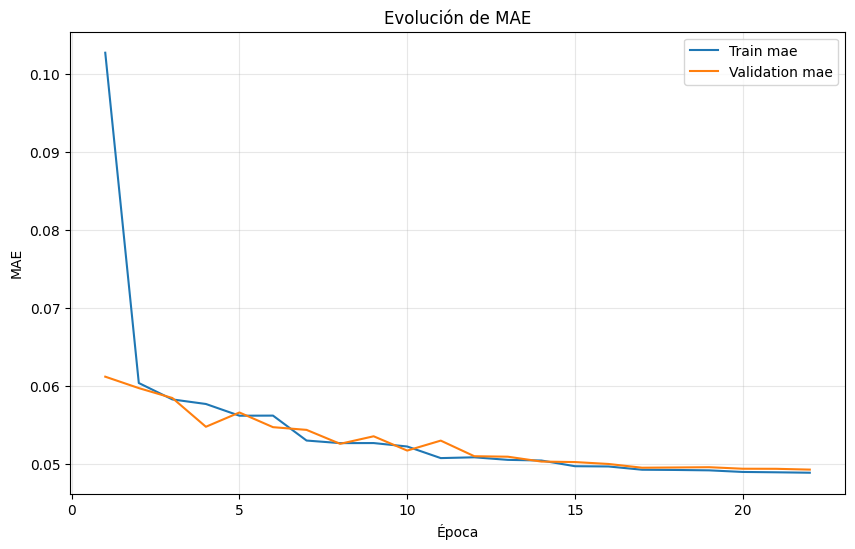

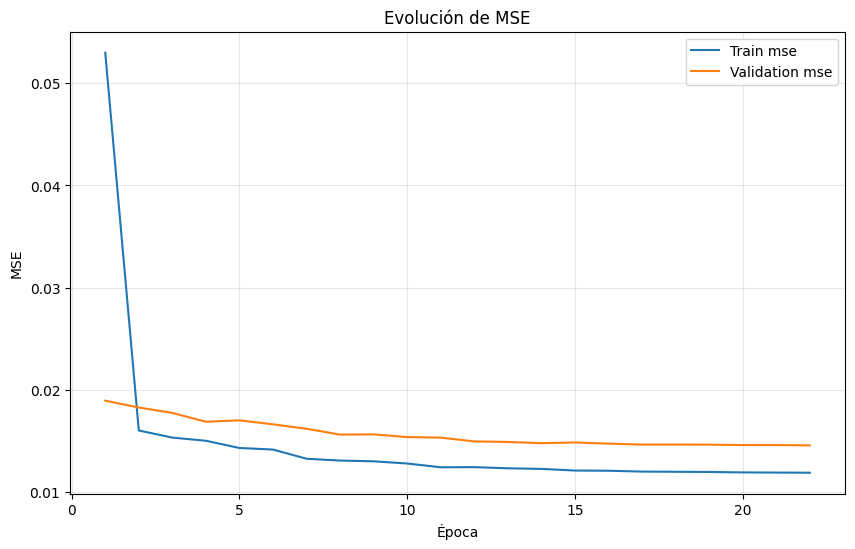

In [29]:
model_data_median_spec = history.history
epochs = range(1, len(model_data_median_spec["loss"]) + 1)

metrics = [
    ("loss", "Función de pérdida"),
    ("mae", "MAE"),
    ("mse", "MSE")
]

for metric, title in metrics:
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, model_data_median_spec[metric], label=f"Train {metric}")
    plt.plot(epochs, model_data_median_spec[f"val_{metric}"], label=f"Validation {metric}")

    plt.xlabel("Época")
    plt.ylabel(metric.upper())
    plt.title(f"Evolución de {title}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

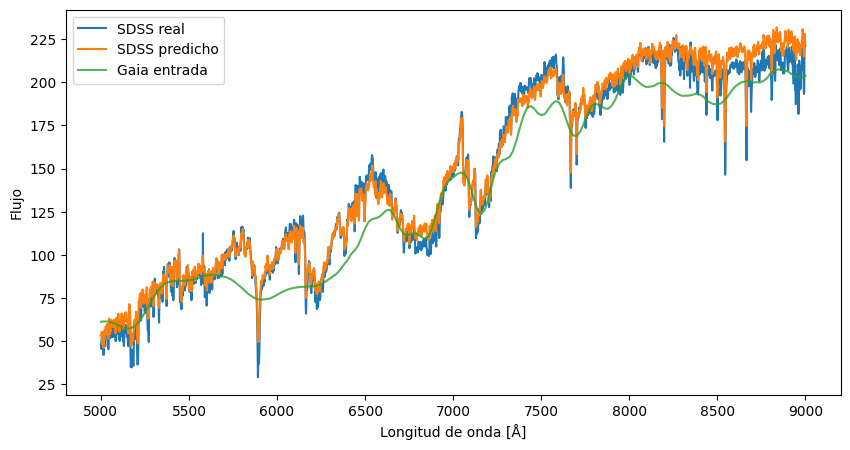

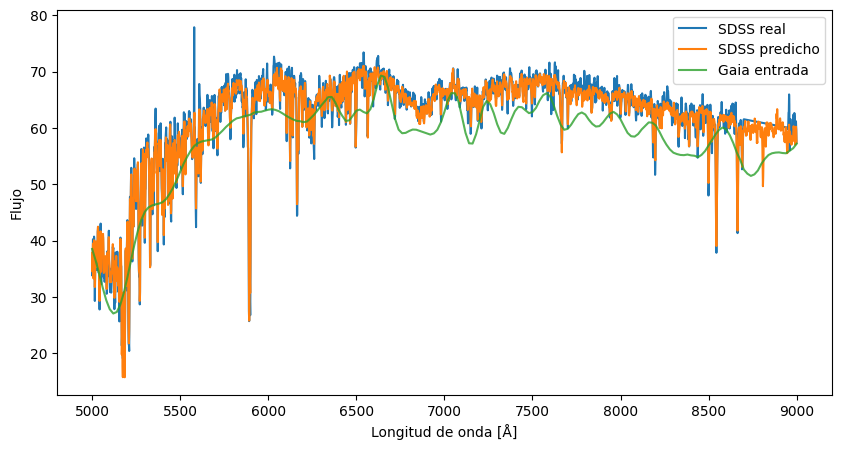

In [30]:
i = 123
#, 23, 178

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_median_spec[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

i = 191

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_median_spec[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

Misma estructura pero con normalización con el máximo por espectro.

In [31]:
# Máximo absoluto por espectro
X_max_train = np.nanmax(np.abs(X_train), axis=1, keepdims=True)
X_max_val = np.nanmax(np.abs(X_val), axis=1, keepdims=True)
X_max_test = np.nanmax(np.abs(X_test), axis=1, keepdims=True)

y_max_train = np.nanmax(np.abs(y_train), axis=1, keepdims=True)
y_max_val = np.nanmax(np.abs(y_val), axis=1, keepdims=True)
y_max_test = np.nanmax(np.abs(y_test), axis=1, keepdims=True)

# Normalización
X_train_norm_max = X_train / X_max_train
X_val_norm_max = X_val / X_max_val
X_test_norm_max = X_test / X_max_test

y_train_norm_max = y_train / y_max_train
y_val_norm_max = y_val / y_max_val
y_test_norm_max = y_test / y_max_test

In [32]:
model_per_spectrum_max = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_per_spectrum_max.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_per_spectrum_max.summary()

history_max_spectrum = model_per_spectrum_max.fit(
    X_train_norm_max,
    y_train_norm_max,
    validation_data=(X_val_norm_max, y_val_norm_max),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - loss: 0.0271 - mae: 0.1511 - mse: 0.0543 - val_loss: 0.0060 - val_mae: 0.0823 - val_mse: 0.0121 - learning_rate: 1.0000e-04
Epoch 2/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.0061 - mae: 0.0772 - mse: 0.0122 - val_loss: 0.0056 - val_mae: 0.0761 - val_mse: 0.0112 - learning_rate: 1.0000e-04
Epoch 3/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0057 - mae: 0.0740 - mse: 0.0114 - val_loss: 0.0055 - val_mae: 0.0748 - val_mse: 0.0110 - learning_rate: 1.0000e-04
Epoch 4/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - loss: 0.0055 - mae: 0.0723 - mse: 0.0109 - val_loss: 0.0053 - val_mae: 0.0719 - val_mse: 0.0106 - learning_rate: 1.0000e-04
Epoch 5/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 0.0056 - mae: 0.0724 - mse: 0.0111 - val_loss: 0.0055 - val_mae: 0.0764 - val_mse: 0.0110 - learning_rate: 1.0000e-04
Epoch 6/50
487/489 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0054 - mae: 0.0717 - mse: 0.0108
Epoc

In [33]:
y_pred_norm_max = model_per_spectrum_max.predict(X_test_norm_max)
y_pred_per_spectrum_max = y_pred_norm_max * y_max_test

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [34]:
test_loss_per_spectrum_max, test_mae_per_spectrum_max, test_mse_per_spectrum_max = model_per_spectrum_max.evaluate(
    X_test_norm_max,
    y_test_norm_max,
    verbose=1
)

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0050 - mae: 0.0665 - mse: 0.0100


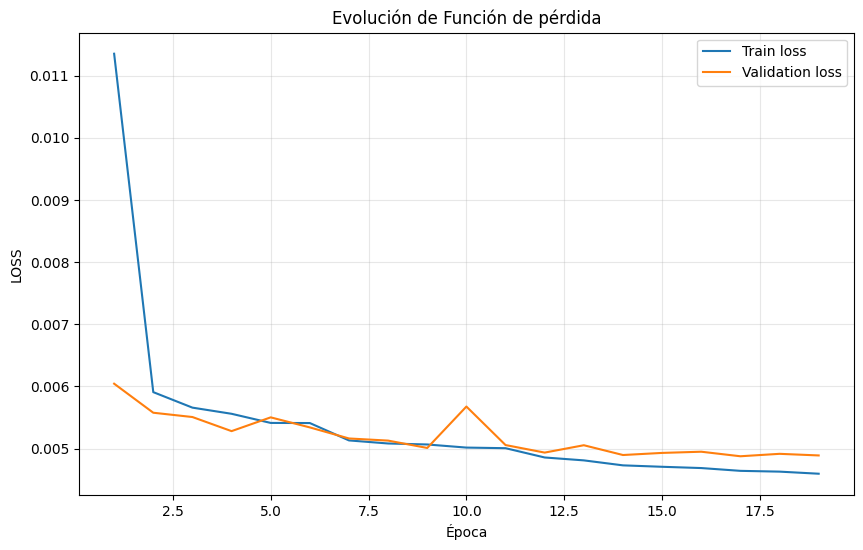

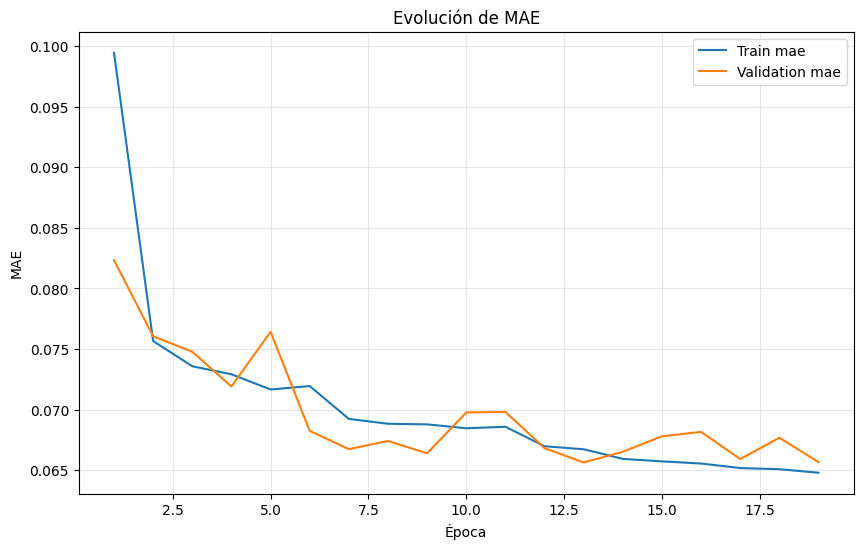

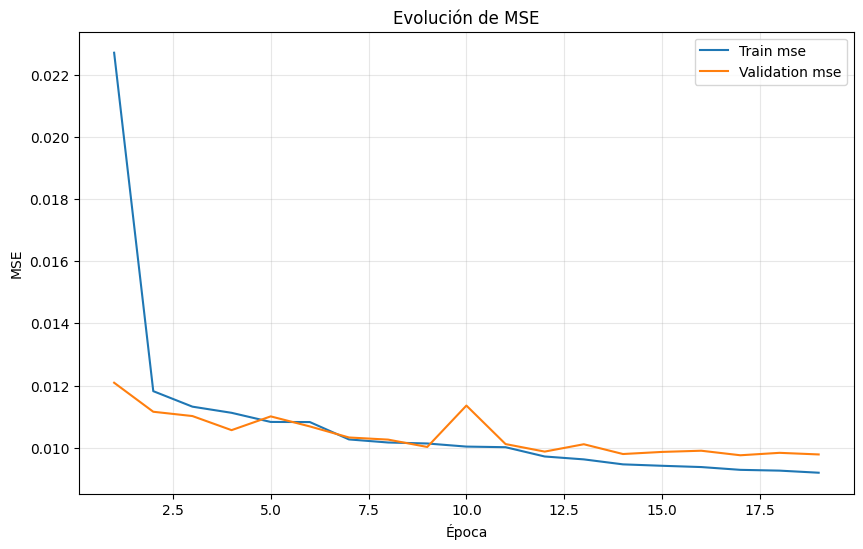

In [35]:
model_data_max = history_max_spectrum.history
epochs = range(1, len(model_data_max["loss"]) + 1)

metrics = [
    ("loss", "Función de pérdida"),
    ("mae", "MAE"),
    ("mse", "MSE")
]

for metric, title in metrics:
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, model_data_max[metric], label=f"Train {metric}")
    plt.plot(epochs, model_data_max[f"val_{metric}"], label=f"Validation {metric}")

    plt.xlabel("Época")
    plt.ylabel(metric.upper())
    plt.title(f"Evolución de {title}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

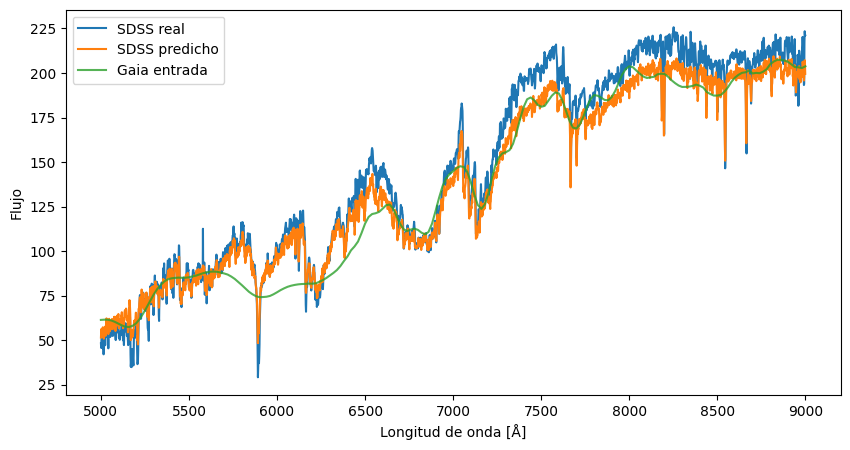

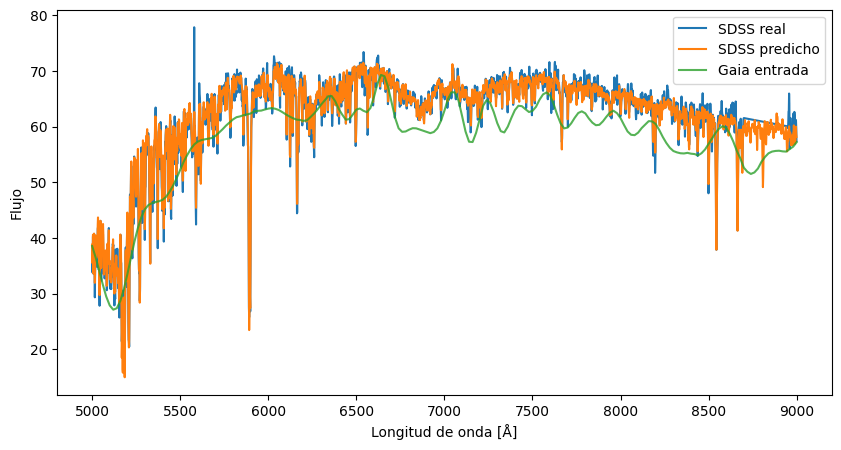

In [36]:
i = 123

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_per_spectrum_max[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

i = 191

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_per_spectrum_max[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

Probamos un modelo diferente par capas convolucionales

In [37]:
n_gaia = X_train_norm.shape[1]
n_sdss = y_train_norm.shape[1]

# Para Conv1D necesitamos forma (n_objetos, n_puntos, canales)
X_train_cnn = X_train_norm[..., None]
X_val_cnn = X_val_norm[..., None]
X_test_cnn = X_test_norm[..., None]

model_cnn = models.Sequential([
    layers.Input(shape=(n_gaia, 1)),

    layers.Conv1D(32, kernel_size=7, padding="same", activation="elu"),
    layers.Conv1D(64, kernel_size=7, padding="same", activation="elu"),
    layers.Conv1D(128, kernel_size=5, padding="same", activation="elu"),

    layers.Flatten(),

    layers.Dense(512),#, activation="elu"),#relu
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_cnn.summary()

NameError: name 'X_train_norm' is not defined

In [ ]:
history = model_cnn.fit(
    X_train_cnn,
    y_train_norm,
    validation_data=(X_val_cnn, y_val_norm),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50


306/306 ━━━━━━━━━━━━━━━━━━━━ 42s 130ms/step - loss: 0.1011 - mae: 0.2689 - mse: 0.3410 - val_loss: 0.0325 - val_mae: 0.1076 - val_mse: 0.1305 - learning_rate: 1.0000e-04
Epoch 2/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - loss: 0.0304 - mae: 0.1092 - mse: 0.1111 - val_loss: 0.0407 - val_mae: 0.1500 - val_mse: 0.1478 - learning_rate: 1.0000e-04
Epoch 3/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - loss: 0.0253 - mae: 0.1028 - mse: 0.0877 - val_loss: 0.0323 - val_mae: 0.1039 - val_mse: 0.1368 - learning_rate: 1.0000e-04
Epoch 4/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - loss: 0.0277 - mae: 0.1005 - mse: 0.1062 - val_loss: 0.0298 - val_mae: 0.1041 - val_mse: 0.1175 - learning_rate: 1.0000e-04
Epoch 5/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - loss: 0.0293 - mae: 0.1027 - mse: 0.1102 - val_loss: 0.0283 - val_mae: 0.1007 - val_mse: 0.1152 - learning_rate: 1.0000e-04
Epoch 6/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - loss: 0.0254 - mae: 0.0990 - mse: 0.0859 - val_lo

In [ ]:
test_loss, test_mae, test_mse = model_cnn.evaluate(
    X_test_cnn,
    y_test_norm,
    verbose=1
)

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0200 - mae: 0.0879 - mse: 0.0624


In [ ]:
y_pred_norm_cnn = model_cnn.predict(X_test_cnn)
y_pred_cnn = y_pred_norm * y_std + y_mean
y_test_recalculated_cnn = y_test_norm * y_std + y_mean

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


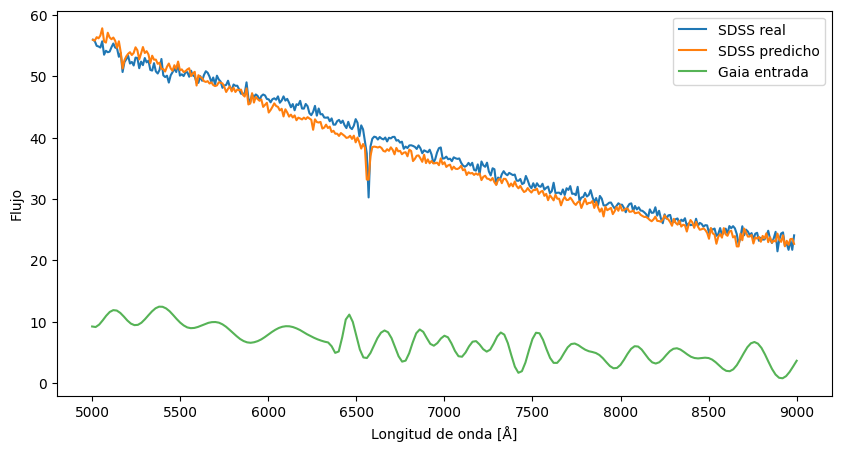

In [ ]:
import matplotlib.pyplot as plt

i = 14

gaia_wavelength_ams = gaia_wavelength * 10
gaia_in_sdss_units_cnn = X_test[i] / 1e-19

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength_binned, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength_binned, y_pred_cnn[i], label="SDSS predicho")
plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()